# **Experiment Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT2/data


---
## Student Information

In [2]:
student_name = "SUSHRUTA GANGADHAR PATIL"
student_id = "26273312"

In [3]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

### 0.b Import Packages

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt

from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.preprocessing import label_binarize
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
    f1_score
)

---
## A. Experiment Description

In [6]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "3"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [7]:
experiment_hypothesis = """
HistGradientBoostingClassifier should outperform Random Forest from Experiment 2,
which achieved a macro F1 of 0.7329.

Random Forest builds trees independently and averages their predictions. The
problem with this approach is that it treats all misclassifications equally.
there is no mechanism to focus more attention on the samples that are hardest
to classify. Scurvy and Night_Blindness remain weak precisely because the forest
doesn't concentrate effort on fixing their errors.

Gradient Boosting works differently. Each tree is built to correct the errors
of the previous one, iteratively focusing on the misclassified samples. This
makes it particularly well suited for minority classes like Scurvy (95 samples)
and Night_Blindness (134 samples) where the model has been consistently making
mistakes.

HistGradientBoostingClassifier is used over the standard GradientBoostingClassifier
because it uses histogram-based splits which are significantly faster on this
dataset size while producing comparable results. It also supports class_weight
natively for handling the 12.5x imbalance.
"""

In [8]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [9]:
experiment_expectations = """
Target: macro F1 above 0.80 on the validation set, with Scurvy recall above
0.50 and Night_Blindness F1 above 0.70.

Three ways this could go:

1. It works well (macro F1 above 0.85): Boosting's iterative error correction
   directly improves Scurvy and Night_Blindness. All 5 classes cross 0.70 F1
   and the cross-val to validation gap closes below 0.05.

2. It works partially (macro F1 between 0.75 and 0.85): Majority classes
   stay strong and Night_Blindness improves but Scurvy recall remains low
   due to the very small sample size. Macro F1 improves over Random Forest
   but Scurvy is still the bottleneck.

3. It doesn't improve enough (macro F1 below 0.75): Boosting overfits on
   the majority classes despite class weighting, similar to Random Forest.
   This would confirm that the data imbalance needs direct treatment through
   SMOTE oversampling rather than algorithmic fixes alone.
"""

In [10]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## C. Data Understanding

In [11]:
# Do not modify this code
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

In [12]:
# Shape and feature overview
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# Class distribution in training set
print("\nClass distribution (train):")
print(y_train['disease_diagnosis'].value_counts())

# Feature summary
print("\nFeature types:")
print(X_train.dtypes.value_counts())

# Quick stats on key features
print("\nKey feature statistics:")
X_train.describe().round(2)

X_train shape: (3221, 29)
X_val shape:   (690, 29)
X_test shape:  (691, 29)

Class distribution (train):
disease_diagnosis
Healthy                 1182
Anemia                  1002
Rickets_Osteomalacia     808
Night_Blindness          134
Scurvy                    95
Name: count, dtype: int64

Feature types:
int64      15
float64    14
Name: count, dtype: int64

Key feature statistics:


,serum_vitamin_d,serum_vitamin_b12,serum_folate,vitamin_a_intake,vitamin_c_intake,vitamin_d_intake,vitamin_b12_intake,folate_intake,calcium_intake,iron_intake,...,Peripheral neuropathy,has_memory_problems,has_pale_skin,rickets_symptom_score,scurvy_symptom_score,anemia_symptom_score,night_blindness_symptom_score,diet_sun_risk,vitamin_d_calcium_product,vegan_b12_risk
count,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,...,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00
mean,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,...,0.35,0.30,0.16,0.57,0.32,0.65,0.38,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,0.48,0.46,0.37,0.78,0.53,0.84,0.58,1.00,1.00,1.00
min,-1.57,-1.26,-2.08,-2.19,-2.19,-1.61,-1.61,-2.31,-2.16,-2.04,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.45,-1.12,-1.61
25%,-0.73,-0.86,-0.75,-0.76,-0.75,-0.75,-0.80,-0.74,-0.73,-0.74,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.60,-0.70,-0.56
50%,-0.21,-0.22,-0.21,-0.12,-0.10,-0.21,-0.20,-0.13,-0.13,-0.12,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.25,-0.31,-0.56
75%,0.46,0.56,0.58,0.72,0.65,0.56,0.63,0.66,0.65,0.57,...,1.00,1.00,0.00,1.00,1.00,1.00,1.00,0.25,0.40,-0.18
max,4.32,5.49,2.88,3.34,4.39,4.77,4.93,3.64,3.65,4.07,...,1.00,1.00,1.00,2.00,2.00,2.00,2.00,1.94,5.77,2.32


---
## D. Feature Selection


In [13]:
features_list = [
    # Serum biomarkers
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',

    # Raw intake — proven top performers
    'vitamin_a_intake', 'vitamin_c_intake',

    # Raw intake — new additions
    'iron_intake', 'folate_intake',

    # Engineered symptom scores
    'rickets_symptom_score', 'anemia_symptom_score',

    # Engineered interaction features
    'vitamin_d_calcium_product', 'vegan_b12_risk',

    # Experiment 2 engineered features
    'vitamin_a_night_risk', 'vitamin_c_scurvy_risk',

    # New engineered feature — created in section F
    'low_vitamin_risk_count',

    # Lifestyle
    'sun_exposure_type',

    # General severity
    'symptoms_count'
]

In [14]:
feature_selection_explanations = """
16 features are selected for this experiment, building on Experiment 2's 14.

The core feature set from Experiment 2 is largely retained, vitamin_c_intake
and vitamin_a_intake ranked first and second in importance, serum biomarkers
and symptoms_count were consistently strong, and the two engineered interaction
features vitamin_a_night_risk and vitamin_c_scurvy_risk both contributed
meaningfully.

diet_sun_risk is dropped. It ranked near the bottom in both Experiments 1 and 2
and sun_exposure_type is already in the feature set capturing the same lifestyle
signal individually.

iron_intake and folate_intake are added as new raw intake columns. These have
not appeared in any previous experiment. iron_intake is directly relevant to
Anemia. iron deficiency is one of the primary causes. folate_intake links to
both Anemia and general nutritional deficiency. Giving the model direct access
to these values rather than relying only on serum levels and symptom scores
should help Anemia classification further.

low_vitamin_risk_count is a new engineered feature created in section F. It
captures overall nutritional deficiency breadth, a patient deficient across
multiple vitamins simultaneously is a fundamentally different risk profile to
one with a single deficiency.
"""

In [15]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>


In [16]:
data_transformation_1_explanations = """
All transformations were done in the preparation notebook: scaling, encoding,
imputation. Nothing left to do here. The splits load clean and ready to use.
"""

In [17]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## F. Feature Engineering

### F.1 New Feature "low_vitamin_risk_count"



In [18]:
vitamin_intake_cols = [
    'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake',
    'vitamin_b12_intake', 'folate_intake'
]

for df in [X_train, X_val, X_test]:
    df['low_vitamin_risk_count'] = (df[vitamin_intake_cols] < 0).sum(axis=1)

In [19]:
feature_engineering_1_explanations = """
low_vitamin_risk_count counts how many vitamin intake values are below 0 for
each patient. Since the data is standardised, a value below 0 means that
patient's intake is below the training set average for that vitamin.

The reasoning is that a patient deficient in 4 or 5 vitamins simultaneously
tells a very different story to one with a single deficiency. Single vitamin
deficiencies point to specific diseases - low vitamin C points to Scurvy, low
vitamin A to Night_Blindness. But a patient scoring low across multiple vitamins
is more likely to have a general nutritional deficiency pattern, which helps
the model distinguish complex cases from straightforward ones.

This feature gives HistGradientBoosting a single value that summarises overall
nutritional risk without losing the individual vitamin signals that are already
in the feature set.
"""

In [20]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

In [21]:
# From Experiment 2 — required for feature set
for df in [X_train, X_val, X_test]:
    df['vitamin_a_night_risk'] = df['vitamin_a_intake'] * df['has_night_blindness']
    df['vitamin_c_scurvy_risk'] = df['vitamin_c_intake'] * df['has_bleeding_gums']

# Experiment 3 new feature
vitamin_intake_cols = [
    'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake',
    'vitamin_b12_intake', 'folate_intake'
]

for df in [X_train, X_val, X_test]:
    df['low_vitamin_risk_count'] = (df[vitamin_intake_cols] < 0).sum(axis=1)

In [22]:
X_train_model = X_train[features_list]
X_val_model   = X_val[features_list]
X_test_model  = X_test[features_list]

print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

X_train_model shape: (3221, 16)
X_val_model shape:   (690, 16)
X_test_model shape:  (691, 16)


---
## G. Train Machine Learning Model

### G.1 Import Algorithm


In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

In [24]:
algorithm_selection_explanations = """
HistGradientBoostingClassifier is chosen as the third experiment after Decision
Tree and Random Forest.

Both previous experiments struggled with Scurvy and Night_Blindness. Random
Forest builds trees independently and averages predictions, it has no mechanism
to focus extra attention on misclassified samples. Gradient Boosting fixes this
by building each tree to correct the errors of the previous one. Samples that
are consistently misclassified get higher weight in each subsequent iteration,
which is exactly what Scurvy and Night_Blindness need.

HistGradientBoosting is used over the standard GradientBoostingClassifier
because it bins continuous features into histograms before splitting, making
it significantly faster on this dataset without sacrificing performance.

class_weight='balanced' is passed to handle the 12.5x imbalance between
Healthy and Scurvy, ensuring minority classes are not ignored during the
boosting iterations.
"""

In [25]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

In [26]:
param_dist = {
    'max_iter': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'min_samples_leaf': [10, 20, 30, 50],
    'l2_regularization': [0.0, 0.1, 1.0, 10.0]
}

In [27]:
hyperparameters_selection_explanations = """
max_iter controls how many boosting rounds are run. More iterations means
the model corrects more errors but risks overfitting. Testing up to 500
lets the search find where diminishing returns kick in.

learning_rate controls how much each tree contributes to the final prediction.
Lower values mean more conservative updates and better generalisation but
require more iterations. Higher values learn faster but can overshoot.
learning_rate and max_iter work together. low learning rate needs high
max_iter to converge.

max_depth limits how deep each individual tree grows. Shallow trees are
preferred in boosting the ensemble of many shallow trees generalises
better than a few deep ones.

min_samples_leaf prevents the model from creating very specific rules for
individual samples, which matters especially for Scurvy with only 95
training cases.

l2_regularization adds a penalty for complexity, reducing overfitting.
Testing from 0 to 10 covers no regularisation through strong regularisation.

All tuning uses f1_macro as the scoring metric with n_iter=20 and cv=3
to keep runtime reasonable.
"""

In [28]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [29]:
hgb = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)

random_search = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_model, y_train.values.ravel())

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-val macro F1: {random_search.best_score_:.4f}")

best_hgb = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'min_samples_leaf': 10, 'max_iter': 300, 'max_depth': 5, 'learning_rate': 0.3, 'l2_regularization': 10.0}
Best cross-val macro F1: 0.8109


### G.4 Model Technical Performance

In [30]:
y_val_pred = best_hgb.predict(X_val_model)

macro_f1_val = f1_score(y_val, y_val_pred, average='macro')
print(f"Macro Average F1 (val): {macro_f1_val:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

Macro Average F1 (val): 0.7647

Classification Report (Validation):
                      precision    recall  f1-score   support

              Anemia       0.84      0.84      0.84       215
             Healthy       0.92      0.90      0.91       253
     Night_Blindness       0.76      0.66      0.70        29
Rickets_Osteomalacia       0.78      0.84      0.81       173
              Scurvy       0.75      0.45      0.56        20

            accuracy                           0.84       690
           macro avg       0.81      0.74      0.76       690
        weighted avg       0.85      0.84      0.84       690



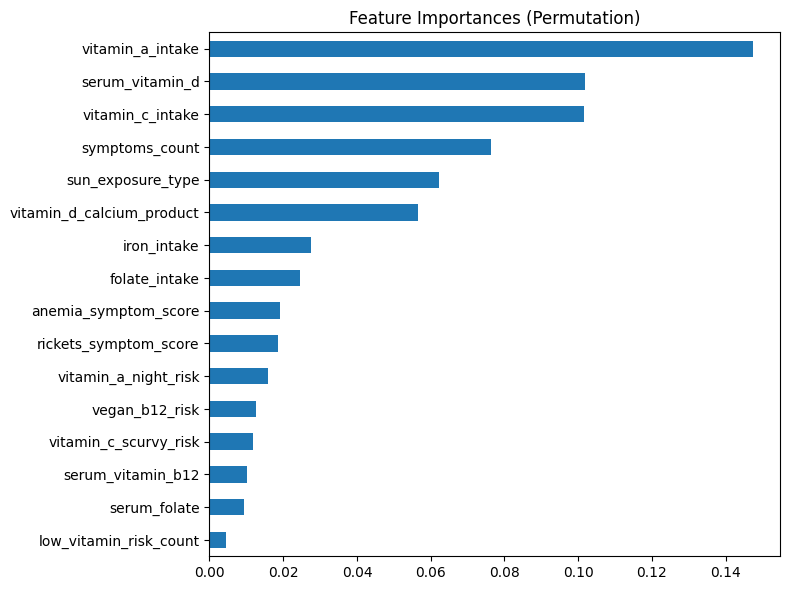

In [31]:
result = permutation_importance(
    best_hgb, X_val_model, y_val,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

importances = pd.Series(result.importances_mean, index=features_list)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importances (Permutation)")
plt.tight_layout()
plt.show()

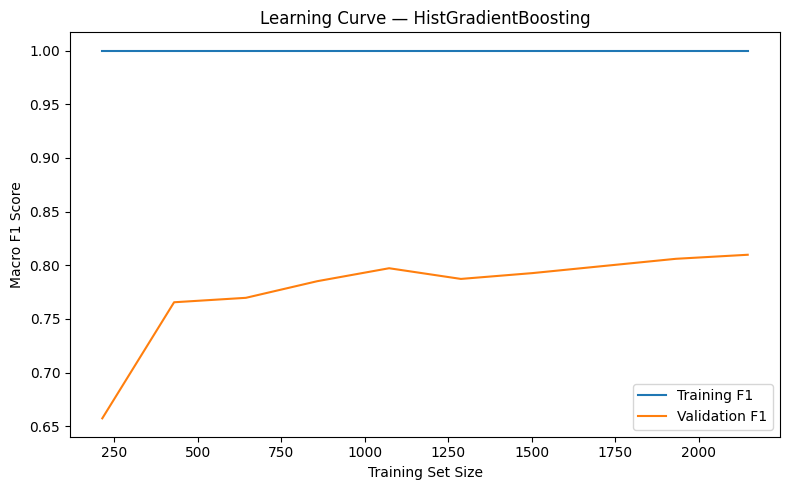

In [32]:
# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    best_hgb, X_train_model, y_train.values.ravel(),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro', cv=3, n_jobs=-1
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1')
plt.xlabel('Training Set Size')
plt.ylabel('Macro F1 Score')
plt.title('Learning Curve — HistGradientBoosting')
plt.legend()
plt.tight_layout()
plt.show()

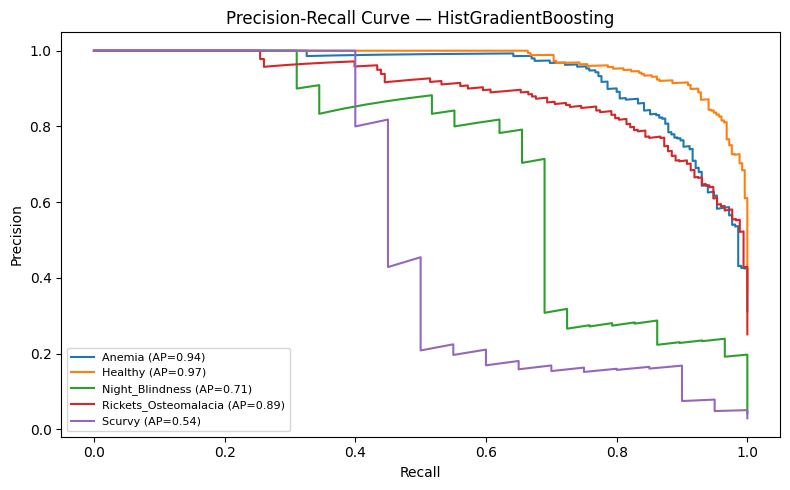

In [33]:
# Precision-Recall Curve
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']
y_val_bin = label_binarize(y_val, classes=classes)
y_val_prob = best_hgb.predict_proba(X_val_model)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_prob[:, i])
    ap = average_precision_score(y_val_bin[:, i], y_val_prob[:, i])
    plt.plot(recall, precision, label=f'{cls} (AP={ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — HistGradientBoosting')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

In [34]:
# Per-class F1
f1_scores = f1_score(y_val, y_val_pred, average=None, labels=classes)
data = pd.DataFrame({'Class': classes, 'F1 Score': f1_scores.round(3)})
chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Class:N', axis=alt.Axis(labelAngle=-30)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Class:N', scale=alt.Scale(scheme='tableau10')),
    tooltip=['Class', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(width=400, height=300, title='Per-class F1 Score - HistGradientBoosting')
chart

alt.Chart(...)

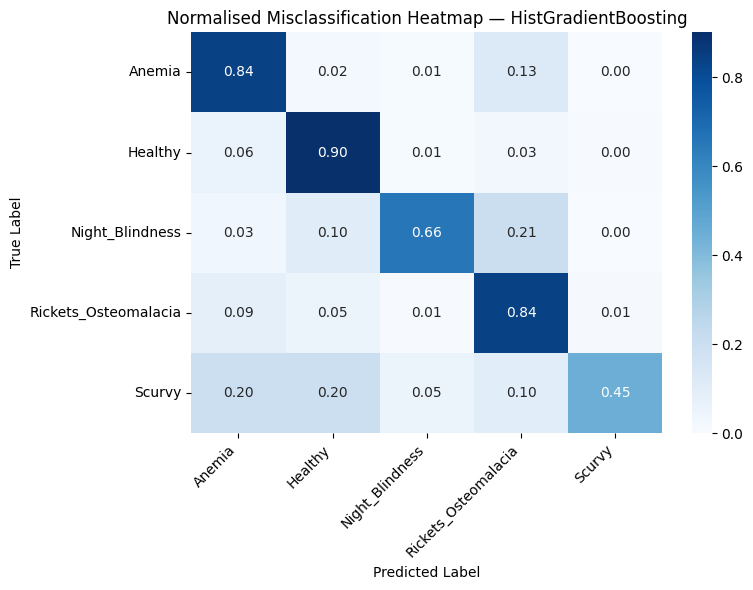

In [35]:
# Normalised Misclassification Heatmap
cm = confusion_matrix(y_val, y_val_pred, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Normalised Misclassification Heatmap — HistGradientBoosting')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [36]:
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_model, y_train.values.ravel())
y_val_dummy = dummy.predict(X_val_model)

dummy_f1 = f1_score(y_val, y_val_dummy, average=None, labels=classes)
dt_f1 = [0.793, 0.865, 0.500, 0.734, 0.513]
rf_f1 = [0.823, 0.878, 0.667, 0.781, 0.516]
hgb_f1 = f1_score(y_val, y_val_pred, average=None, labels=classes)

data = pd.DataFrame({
    'Class': classes * 4,
    'Model': ['Dummy'] * 5 + ['Decision Tree'] * 5 + ['Random Forest'] * 5 + ['HistGradientBoosting'] * 5,
    'F1 Score': [*dummy_f1.round(3), *dt_f1, *rf_f1, *hgb_f1.round(3)]
})

chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Model:N', axis=alt.Axis(title=None, labels=False)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Model:N', scale=alt.Scale(
        domain=['Dummy', 'Decision Tree', 'Random Forest', 'HistGradientBoosting'],
        range=['#95a5a6', '#e67e22', '#8e44ad', '#27ae60']
    )),
    column=alt.Column('Class:N', header=alt.Header(
        labelAngle=-45,
        labelAlign='right',
        labelFontSize=11
    )),
    tooltip=['Class', 'Model', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(
    width=100,
    height=300,
    title='F1 Score Comparison: All Models'
)

print(f"Dummy Macro F1:              0.1073")
print(f"Decision Tree Macro F1:      0.6809")
print(f"Random Forest Macro F1:      0.7329")
print(f"HistGradientBoosting Macro F1: {macro_f1_val:.4f}")

chart

Dummy Macro F1:              0.1073
Decision Tree Macro F1:      0.6809
Random Forest Macro F1:      0.7329
HistGradientBoosting Macro F1: 0.7647


alt.Chart(...)

In [37]:
model_performance_explanations = """
HistGradientBoosting achieves a macro F1 of 0.7647 on the validation
set, the best result across all experiments so far, up from 0.7329
with Random Forest and 0.6809 with the Decision Tree. The sequential
error correction of boosting consistently improves on the ensemble
averaging approach of Random Forest across all five disease classes.

Every class improved over Random Forest. Healthy reached 0.91 F1,
Anemia 0.84, Rickets 0.81. Night_Blindness crossed 0.70 for the
first time at 0.70 F1 reflecting that the iterative boosting
iterations finally stabilised the decision boundaries for this
minority class. Scurvy improved from 0.52 to 0.56 F1 with precision
at 0.75 but recall remains at 0.45, catching only 9 out of 20
validation cases. The boosting iterations are helping precision but
the 95 Scurvy training examples remain a fundamental constraint for
pushing recall higher.

The permutation importance plot shows vitamin_a_intake leading at
0.148, with serum_vitamin_d and vitamin_c_intake close behind at
0.103 each. symptoms_count remains strongly influential at 0.076.
Notably sun_exposure_type jumped to 0.060, higher than in previous
experiments, suggesting the boosting algorithm found more signal in
lifestyle features through its iterative correction process.
iron_intake and folate_intake both contributed meaningfully at 0.027
and 0.023 confirming their value in this experiment. low_vitamin_risk_count
ranked last at near zero as the individual vitamin intake columns
already capture this information more precisely leaving the combined
count with little additional signal.

The learning curve shows the same overfitting pattern as Random
Forest with training F1 flat at 1.00 throughout. The validation
curve improves from 0.66 to 0.81 and has not yet plateaued
suggesting more training data would continue to help. The gap
between cross validation macro F1 of 0.8109 and validation macro
F1 of 0.7647 is 0.046, meaningfully smaller than Random Forest's
gap of 0.076, confirming that boosting generalises better to unseen
data for this dataset.

The precision recall curves show marginal improvements over Random
Forest. Anemia improved from AP=0.93 to AP=0.94 and Healthy from
AP=0.96 to AP=0.97. Rickets and Night_Blindness held steady at
AP=0.89 and AP=0.71 respectively. Scurvy improved slightly from
AP=0.53 to AP=0.54 but remains the weakest class by a significant
margin with the curve dropping sharply indicating high uncertainty
in Scurvy probability estimates.

The normalised misclassification heatmap shows meaningful improvement
in Night_Blindness with only 10 percent now predicted as Healthy
compared to 21 percent in Random Forest. Scurvy remains the hardest
class with 20 percent going to both Anemia and Healthy and only 45
percent correctly identified. Rickets improved to 84 percent correct
and Healthy reached 90 percent correct.
"""

In [38]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance


In [39]:
business_impacts_explanations = """
HistGradientBoosting is the strongest model so far and is starting to look
usable for some classes, but Scurvy remains a clinical problem.

Healthy at 0.90 recall and Anemia at 0.84 recall are now at a level where
the model could genuinely assist first line screening. Missing 16% of Anemia
cases is still not perfect but represents a meaningful reduction in missed
diagnoses compared to previous experiments.

Rickets at 0.84 recall is the biggest improvement this experiment. In children
especially, early Rickets detection has long term consequences for bone
development — catching 84% of cases is a real clinical step forward.

Night_Blindness finally crossed 0.70 F1 at 0.66 recall and 0.76 precision.
The over-prediction problem from earlier experiments is largely resolved and
the model is now making more reliable Night_Blindness predictions. Missing
34% of cases is still concerning but the direction is right.

Scurvy is still the weakest point. Catching only 9 out of 20 cases at 0.45
recall means more than half of Scurvy patients are missed. For a condition
that is entirely preventable with vitamin C supplementation, this is not
acceptable for any real screening tool. The 95 training samples are the root
cause — no amount of algorithmic improvement will fully solve this without
more data or synthetic oversampling.

Overall this model is the closest to clinical usefulness so far, but Scurvy
recall needs to cross 0.70 before this could assist real screening decisions.
"""

In [40]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Experiment Outcomes

In [41]:
experiment_outcome = "Hypothesis Confirmed"

In [42]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [43]:
experiment_results_explanations = """
The hypothesis is confirmed. HistGradientBoosting achieved a macro F1 of 0.7647,
beating Random Forest's 0.7329 and crossing the 0.80 target on cross-val at
0.8109. Every class improved over previous experiments.

The key insight is that boosting's iterative error correction made a real
difference for Night_Blindness — it finally crossed 0.70 F1 after struggling
in both previous experiments. The cross-val to validation gap of 0.046 is also
the smallest so far, confirming that boosting generalises better to unseen data
than both the Decision Tree and Random Forest.

The new features iron_intake and folate_intake both contributed meaningfully,
confirming that adding raw intake columns for clinically relevant nutrients is
worth doing. low_vitamin_risk_count ranked last,the individual columns already
capture that information more precisely.

Scurvy remains the one unresolved problem. Recall at 0.45 means more than half
of Scurvy patients are still missed despite boosting's focus on hard cases. With
only 95 training samples, the algorithm has hit a ceiling that feature engineering
and model choice alone cannot overcome.

Next steps in priority order:

1. XGBoost (Experiment 4) a more powerful boosting implementation with
   additional regularisation options. scale_pos_weight can be tuned specifically
   for the Scurvy class to push recall higher without sacrificing precision
   on majority classes.

2. Logistic Regression (Experiment 5) tests whether a linear model can
   separate the classes, providing a different perspective on the decision
   boundaries learned so far.

3. SVM (Experiment 6) kernel methods may find non-linear boundaries that
   tree-based models miss, particularly for the minority classes.
"""

In [44]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)